<a href="https://colab.research.google.com/github/ItsHaque/Federated-Learning/blob/main/DiabetesPredictionUsingFLv6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Cleaning & Normalization

In [ ]:
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_zeros]=df[cols_with_zeros].replace(0,np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Client & Dataset Sliting

In [ ]:
clients = 3
indices = np.random.permutation(len(X))
client_splits = np.array_split(indices, clients)

client_data = []
for i, idx in enumerate(client_splits):
  X_train,X_test,y_train,y_test = train_test_split(X[idx],y[idx], test_size=0.2, random_state=42)
  client_data.append({
      'client_id' : i,
      'X_train' : X_train,
      'X_test' : X_test,
      'y_train' : y_train,
      'y_test' : y_test
      })
  print(f"Hospital {i+1}: train: {len(X_train)} test: {len(X_test)} positiverate: {y_train.mean():.2f}")

Hospital 1: train: 204 test: 52 positiverate: 0.39
Hospital 2: train: 204 test: 52 positiverate: 0.31
Hospital 3: train: 204 test: 52 positiverate: 0.31


# Client Visualization

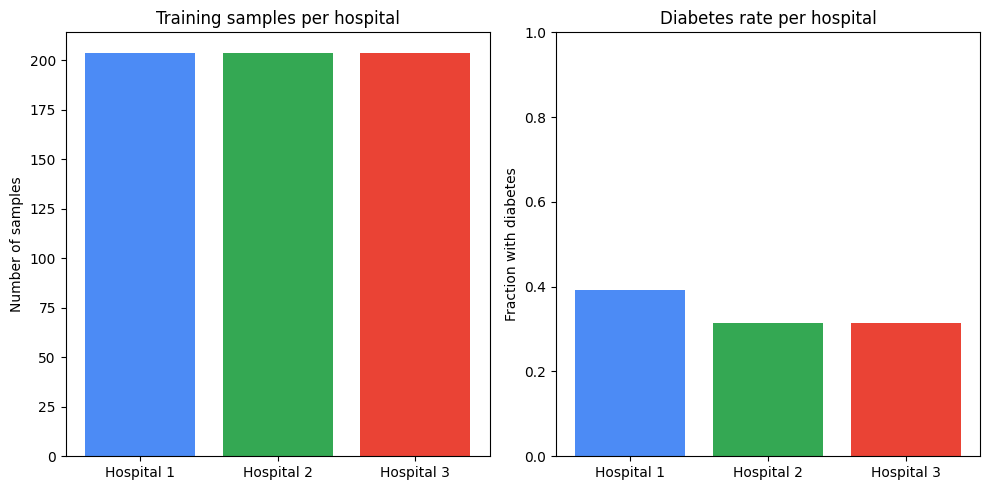

In [ ]:
labels = [f"Hospital {c['client_id']+1}" for c in client_data]
train_sizes = [len(c['X_train']) for c in client_data]
pos_rates = [c['y_train'].mean() for c in client_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.bar(labels, train_sizes, color=["#4C8BF5", "#34A853", "#EA4335"])
ax1.set_title("Training samples per hospital")
ax1.set_ylabel("Number of samples")

ax2.bar(labels, pos_rates, color=["#4C8BF5", "#34A853", "#EA4335"])
ax2.set_title("Diabetes rate per hospital")
ax2.set_ylabel("Fraction with diabetes")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Model Building

In [ ]:
import torch
import torch.nn as nn

class DiabetesModel(nn.Module):
  def __init__(self):
    super(DiabetesModel, self).__init__()
    self.net = nn.Sequential(
        nn.Linear(8, 16),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(16,8),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(8,1),
    )
  def forward(self,x):
    return self.net(x)

model = DiabetesModel()
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")


DiabetesModel(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Total trainable parameters: 289


# Local Training Method Definition

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def train_local(model, client, epochs =10, lr =0.01, apply_dp=True):
  """Train the model on a single client's local data."""

  X_train = torch.tensor(client['X_train'], dtype=torch.float32)
  y_train = torch.tensor(client['y_train'], dtype=torch.float32).unsqueeze(1)

  dataset = TensorDataset(X_train, y_train)
  loader = DataLoader(dataset, batch_size=32, shuffle=True)

  pos_weight = torch.tensor([101/55])
  criterion = nn.BCEWithLogitsLoss(pos_weight= pos_weight)
  optimizer = optim.Adam(model.parameters(), lr=lr)

  model.train()
  for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in loader:
      optimizer.zero_grad()
      preds = model(batch_X)
      loss = criterion(preds, batch_y)
      loss.backward()

      # Apply gradient clipping and add noise for Differential Privacy
      if apply_dp:
        # Calculate the effective standard deviation for noise
        std_dev = DP_NOISE_MULTIPLIER * DP_CLIP_NORM

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=DP_CLIP_NORM)

        # Add Gaussian noise to gradients
        for param in model.parameters():
            if param.grad is not None:
                noise = torch.randn_like(param.grad) * std_dev
                param.grad += noise

      optimizer.step()
      epoch_loss += loss.item()

    avg_loss = epoch_loss/len(loader)

  # print(f" Hospital {client['client_id']+1} -> final loss: {avg_loss:.4f}")

  return model.state_dict()

# Testing For a Client

In [ ]:
import copy

global_model = DiabetesModel()

local_weights = train_local(copy.deepcopy(global_model), client_data[0], epochs = 10)
print("\nLocal weights returned successfully")
print(f"weight keys: {list(local_weights.keys())}")


Local weights returned successfully
weight keys: ['net.0.weight', 'net.0.bias', 'net.3.weight', 'net.3.bias', 'net.6.weight', 'net.6.bias']


#FedAvg Method Definition

In [ ]:
import copy

def federated_average(global_model, local_weights_list, client_sizes):
  """Average the local weights weighted by each client's database size."""
  total_samples = sum(client_sizes)
  avg_weights = copy.deepcopy(local_weights_list[0])

  for key in avg_weights.keys():
    avg_weights[key] = torch.zeros_like(avg_weights[key])

    for i, local_weights in enumerate(local_weights_list):
      weight = client_sizes[i] / total_samples
      avg_weights[key] += weight * local_weights[key]

  global_model.load_state_dict(avg_weights)
  return global_model

# Core FL Training

### Adding Differential Privacy

To enhance privacy in our federated learning setup, we'll introduce Differential Privacy (DP) mechanisms during local training. Specifically, we'll implement **Gaussian clipping** and **calibrated noise addition** to the gradients.

This involves:
1.  **Gradient Clipping**: Limiting the L2 norm of gradients to a maximum value (`DP_CLIP_NORM`). This prevents individual data points from having an overly large impact on the model updates.
2.  **Noise Addition**: Adding Gaussian noise to the clipped gradients. The scale of this noise is determined by `DP_NOISE_MULTIPLIER` and `DP_CLIP_NORM`, ensuring that the updates are differentially private.

Adding differential privacy often comes with a trade-off in model accuracy, as it intentionally introduces randomness to protect sensitive information.

In [ ]:
# Differential Privacy Parameters
DP_CLIP_NORM = 1.0  # Maximum L2 norm for gradient clipping
DP_NOISE_MULTIPLIER = 0.5 # Multiplier for Gaussian noise standard deviation

print(f"DP_CLIP_NORM: {DP_CLIP_NORM}")
print(f"DP_NOISE_MULTIPLIER: {DP_NOISE_MULTIPLIER}")

DP_CLIP_NORM: 1.0
DP_NOISE_MULTIPLIER: 0.5


We will now modify the `train_local` function and the federated training loops to incorporate these differential privacy mechanisms. After these modifications, you will need to re-run the federated training and evaluation cells to observe the impact on model performance.

In [ ]:
NUM_ROUNDS = 150
EPOCHS     = 20
LR         = 0.001

global_model = DiabetesModel()
round_losses = []

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n── Round {round_num}/{NUM_ROUNDS} ──")

    local_weights_list = []
    client_sizes       = []

    # Each hospital trains locally
    for client in client_data:
        local_model   = copy.deepcopy(global_model)
        local_weights = train_local(local_model, client, epochs=EPOCHS, lr=LR)
        local_weights_list.append(local_weights)
        client_sizes.append(len(client["X_train"]))

    # Server aggregates
    global_model = federated_average(global_model, local_weights_list, client_sizes)
    # print(f"  Server aggregated weights from {len(client_data)} hospitals")


── Round 1/150 ──

── Round 2/150 ──

── Round 3/150 ──

── Round 4/150 ──

── Round 5/150 ──

── Round 6/150 ──

── Round 7/150 ──

── Round 8/150 ──

── Round 9/150 ──

── Round 10/150 ──

── Round 11/150 ──

── Round 12/150 ──

── Round 13/150 ──

── Round 14/150 ──

── Round 15/150 ──

── Round 16/150 ──

── Round 17/150 ──

── Round 18/150 ──

── Round 19/150 ──

── Round 20/150 ──

── Round 21/150 ──

── Round 22/150 ──

── Round 23/150 ──

── Round 24/150 ──

── Round 25/150 ──

── Round 26/150 ──

── Round 27/150 ──

── Round 28/150 ──

── Round 29/150 ──

── Round 30/150 ──

── Round 31/150 ──

── Round 32/150 ──

── Round 33/150 ──

── Round 34/150 ──

── Round 35/150 ──

── Round 36/150 ──

── Round 37/150 ──

── Round 38/150 ──

── Round 39/150 ──

── Round 40/150 ──

── Round 41/150 ──

── Round 42/150 ──

── Round 43/150 ──

── Round 44/150 ──

── Round 45/150 ──

── Round 46/150 ──

── Round 47/150 ──

── Round 48/150 ──

── Round 49/150 ──

── Round 50/150 ──

── Round

# Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

global_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
  for client in client_data:
    X_test = torch.tensor(client['X_test'], dtype=torch.float32)
    y_test = client['y_test']

    preds = global_model(X_test).squeeze().numpy()
    preds_binary = (preds >= 0.5).astype(int)

    all_preds.extend(preds_binary)
    all_labels.extend(y_test)

print(f"--- Final Global Model Performance (with DP) ---")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f'\nDetailed Report')
print(classification_report(all_labels, all_preds, target_names = ['No Diabetes', 'Diabetes']))

--- Final Global Model Performance (with DP) ---
Accuracy: 0.7628

Detailed Report
              precision    recall  f1-score   support

 No Diabetes       0.76      0.91      0.82        96
    Diabetes       0.78      0.53      0.63        60

    accuracy                           0.76       156
   macro avg       0.77      0.72      0.73       156
weighted avg       0.77      0.76      0.75       156



# Visualization

Round 01 → Accuracy: 0.6154
Round 02 → Accuracy: 0.6154
Round 03 → Accuracy: 0.6154
Round 04 → Accuracy: 0.6154
Round 05 → Accuracy: 0.6154
Round 06 → Accuracy: 0.6154
Round 07 → Accuracy: 0.6154
Round 08 → Accuracy: 0.6218
Round 09 → Accuracy: 0.6218
Round 10 → Accuracy: 0.6282
Round 11 → Accuracy: 0.6218
Round 12 → Accuracy: 0.6218
Round 13 → Accuracy: 0.6218
Round 14 → Accuracy: 0.6282
Round 15 → Accuracy: 0.6282
Round 16 → Accuracy: 0.6282
Round 17 → Accuracy: 0.6282
Round 18 → Accuracy: 0.6282
Round 19 → Accuracy: 0.6346
Round 20 → Accuracy: 0.6410
Round 21 → Accuracy: 0.6474
Round 22 → Accuracy: 0.6667
Round 23 → Accuracy: 0.6731
Round 24 → Accuracy: 0.6731
Round 25 → Accuracy: 0.6667
Round 26 → Accuracy: 0.6795
Round 27 → Accuracy: 0.6923
Round 28 → Accuracy: 0.7179
Round 29 → Accuracy: 0.7179
Round 30 → Accuracy: 0.7372
Round 31 → Accuracy: 0.7372
Round 32 → Accuracy: 0.7500
Round 33 → Accuracy: 0.7564
Round 34 → Accuracy: 0.7564
Round 35 → Accuracy: 0.7500
Round 36 → Accuracy:

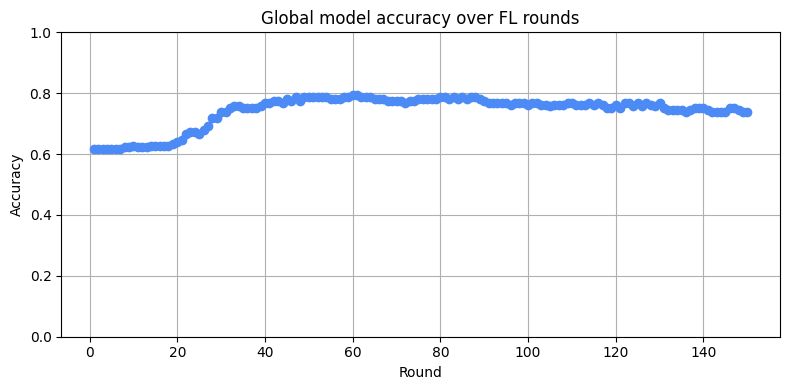

In [ ]:
global_model = DiabetesModel()
round_accuracies = []

for round_num in range(1, NUM_ROUNDS + 1):
    local_weights_list = []
    client_sizes       = []

    for client in client_data:
        local_model   = copy.deepcopy(global_model)
        local_weights = train_local(local_model, client, epochs=EPOCHS, lr=LR)
        local_weights_list.append(local_weights)
        client_sizes.append(len(client["X_train"]))

    global_model = federated_average(global_model, local_weights_list, client_sizes)

    # Evaluate after each round
    global_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for client in client_data:
            X_test = torch.tensor(client["X_test"], dtype=torch.float32)
            preds  = global_model(X_test).squeeze().numpy()
            all_preds.extend((preds >= 0.5).astype(int))
            all_labels.extend(client["y_test"])

    acc = accuracy_score(all_labels, all_preds)
    round_accuracies.append(acc)
    print(f"Round {round_num:02d} → Accuracy: {acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_ROUNDS + 1), round_accuracies, marker="o", color="#4C8BF5")
plt.title("Global model accuracy over FL rounds")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

### Feature Importance - Correlation Heatmap

To understand the relationship between features and the target variable, as well as the relationships among features, we can use a correlation heatmap. This helps in identifying potentially important features for predicting diabetes and checking for multicollinearity.

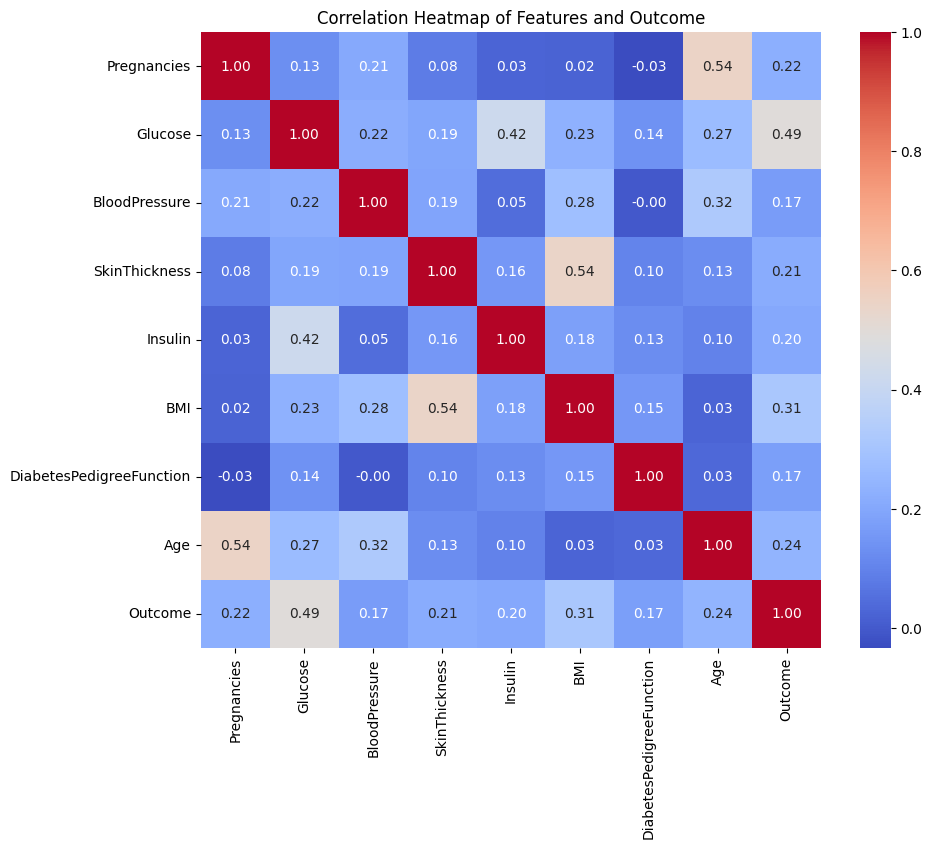

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the original DataFrame
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features and Outcome')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

# Re-run evaluation to get probability scores for ROC-AUC
global_model.eval()
all_probs = []
all_labels_auc = []

with torch.no_grad():
    for client in client_data:
        X_test = torch.tensor(client['X_test'], dtype=torch.float32)
        y_test = client['y_test']

        logits = global_model(X_test).squeeze()
        probs = torch.sigmoid(logits).numpy()

        all_probs.extend(probs)
        all_labels_auc.extend(y_test)

roc_auc = roc_auc_score(all_labels_auc, all_probs)
print(f"ROC-AUC Score for Global Model (with DP): {roc_auc:.4f}")

ROC-AUC Score for Global Model (with DP): 0.8655


### Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's predictions versus the actual outcomes, showing true positives, true negatives, false positives, and false negatives.

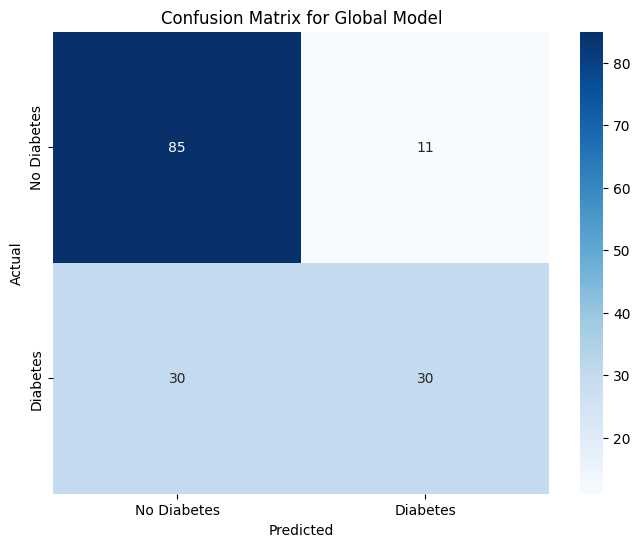

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for Global Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Centralized Model Training and Evaluation

To provide a baseline for comparison, we will train a traditional centralized model using all the training data combined from all clients. We will then evaluate its performance using the same metrics as the federated model.

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Combine all client training data for centralized training
X_train_central = torch.tensor(np.concatenate([c['X_train'] for c in client_data]), dtype=torch.float32)
y_train_central = torch.tensor(np.concatenate([c['y_train'] for c in client_data]), dtype=torch.float32).unsqueeze(1)

# Combine all client test data for centralized evaluation
X_test_central = torch.tensor(np.concatenate([c['X_test'] for c in client_data]), dtype=torch.float32)
y_test_central = np.concatenate([c['y_test'] for c in client_data])

def train_centralized_model(model, X_train, y_train, epochs=EPOCHS, lr=LR):
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    pos_weight = torch.tensor([101/55]) # Using the same pos_weight as local training
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
    return model

print("Training centralized model...")
central_model = DiabetesModel()
central_model = train_centralized_model(central_model, X_train_central, y_train_central, epochs=NUM_ROUNDS, lr=LR)
print("Centralized model training complete.")

Training centralized model...
Centralized model training complete.


--- Centralized Model Performance ---
Accuracy: 0.8077
ROC-AUC Score: 0.8536

Detailed Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.84      0.84        96
    Diabetes       0.75      0.75      0.75        60

    accuracy                           0.81       156
   macro avg       0.80      0.80      0.80       156
weighted avg       0.81      0.81      0.81       156



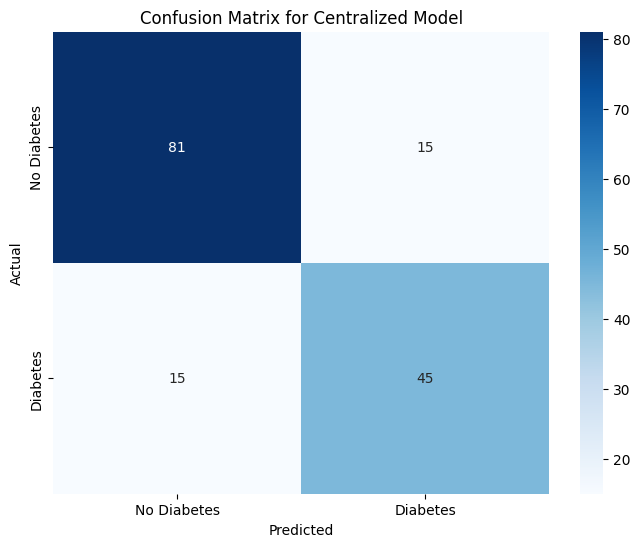

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

central_model.eval()
all_preds_central = []
all_probs_central = []

with torch.no_grad():
    logits_central = central_model(X_test_central).squeeze()
    probs_central = torch.sigmoid(logits_central).numpy()
    preds_binary_central = (probs_central >= 0.5).astype(int)

    all_preds_central.extend(preds_binary_central)
    all_probs_central.extend(probs_central)

accuracy_central = accuracy_score(y_test_central, all_preds_central)
roc_auc_central = roc_auc_score(y_test_central, all_probs_central)

print(f"--- Centralized Model Performance ---")
print(f"Accuracy: {accuracy_central:.4f}")
print(f"ROC-AUC Score: {roc_auc_central:.4f}")
print(f'\nDetailed Report:')
print(classification_report(y_test_central, all_preds_central, target_names=['No Diabetes', 'Diabetes']))

cm_central = confusion_matrix(y_test_central, all_preds_central)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_central, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for Centralized Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import copy

# --- Train Federated Model WITHOUT DP ---
print("\n--- Training Federated Model WITHOUT DP ---")
non_dp_global_model = DiabetesModel()

for round_num in range(1, NUM_ROUNDS + 1):
    local_weights_list_non_dp = []
    client_sizes_non_dp = []

    # Each hospital trains locally without DP
    for client in client_data:
        local_model_non_dp = copy.deepcopy(non_dp_global_model)
        # Pass apply_dp=False to train_local
        local_weights_non_dp = train_local(local_model_non_dp, client, epochs=EPOCHS, lr=LR, apply_dp=False)
        local_weights_list_non_dp.append(local_weights_non_dp)
        client_sizes_non_dp.append(len(client["X_train"]))

    # Server aggregates
    non_dp_global_model = federated_average(non_dp_global_model, local_weights_list_non_dp, client_sizes_non_dp)

# --- Evaluate Individual Hospital Performance ---
print("\n--- Evaluating Individual Hospital Performance ---")

hospital_accuracies_dp = []
hospital_accuracies_non_dp = []

with torch.no_grad():
    for client in client_data:
        X_test = torch.tensor(client['X_test'], dtype=torch.float32)
        y_test = client['y_test']

        # Evaluate DP-enabled model
        global_model.eval() # Ensure the DP-enabled model is in eval mode
        preds_dp = global_model(X_test).squeeze().numpy()
        preds_binary_dp = (preds_dp >= 0.5).astype(int)
        acc_dp = accuracy_score(y_test, preds_binary_dp)
        hospital_accuracies_dp.append(acc_dp)

        # Evaluate Non-DP model
        non_dp_global_model.eval() # Ensure the non-DP model is in eval mode
        preds_non_dp = non_dp_global_model(X_test).squeeze().numpy()
        preds_binary_non_dp = (preds_non_dp >= 0.5).astype(int)
        acc_non_dp = accuracy_score(y_test, preds_binary_non_dp)
        hospital_accuracies_non_dp.append(acc_non_dp)

# --- Display Comparison Table ---
comparison_table = "### Individual Hospital Performance: DP vs. No DP\n\n"
comparison_table += "| Hospital | Accuracy (with DP) | Accuracy (without DP) |\n"
comparison_table += "|:---------|:-------------------|:----------------------|\n"

for i, client in enumerate(client_data):
    comparison_table += f"| {client['client_id']+1}        | {hospital_accuracies_dp[i]:.4f}             | {hospital_accuracies_non_dp[i]:.4f}                  |\n"

print(comparison_table)



--- Training Federated Model WITHOUT DP ---

--- Evaluating Individual Hospital Performance ---
### Individual Hospital Performance: DP vs. No DP

| Hospital | Accuracy (with DP) | Accuracy (without DP) |
|:---------|:-------------------|:----------------------|
| 1        | 0.7308             | 0.7692                  |
| 2        | 0.7115             | 0.6731                  |
| 3        | 0.7692             | 0.8077                  |



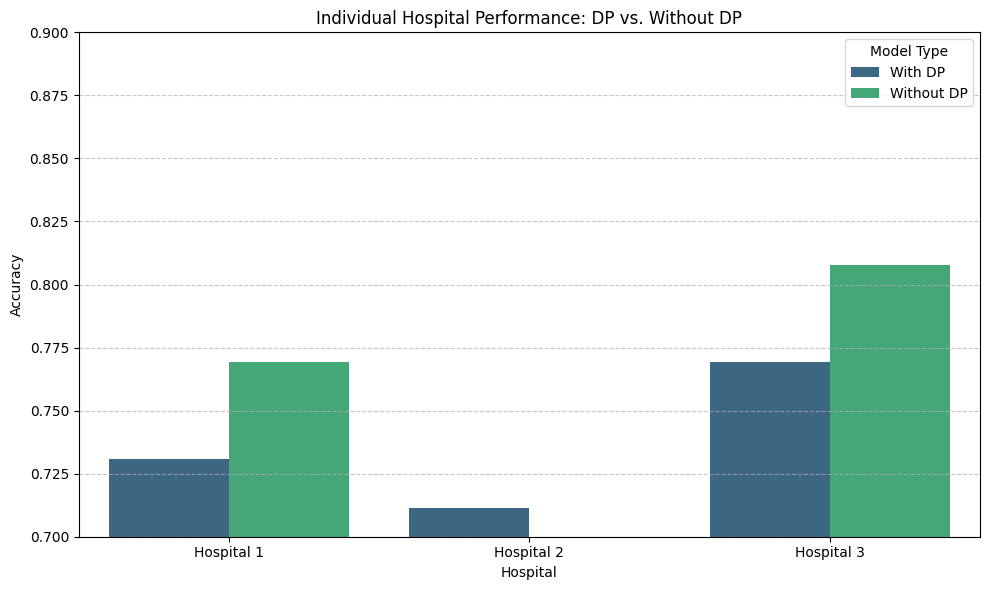

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
hospital_ids = [f"Hospital {c['client_id']+1}" for c in client_data]
plot_data = {
    'Hospital': hospital_ids * 2,
    'Accuracy': hospital_accuracies_dp + hospital_accuracies_non_dp,
    'Model Type': ['With DP'] * len(hospital_accuracies_dp) + ['Without DP'] * len(hospital_accuracies_non_dp)
}
df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Hospital', y='Accuracy', hue='Model Type', data=df_plot, palette='viridis')
plt.title('Individual Hospital Performance: DP vs. Without DP')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.9) # Set a reasonable y-limit for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

non_dp_global_model.eval()

all_preds_non_dp = []
all_labels_non_dp = []

with torch.no_grad():
  for client in client_data:
    X_test = torch.tensor(client['X_test'], dtype=torch.float32)
    y_test = client['y_test']

    preds = non_dp_global_model(X_test).squeeze().numpy()
    preds_binary = (preds >= 0.5).astype(int)

    all_preds_non_dp.extend(preds_binary)
    all_labels_non_dp.extend(y_test)

overall_accuracy_non_dp = accuracy_score(all_labels_non_dp, all_preds_non_dp)
print(f"--- Overall Federated Model Performance (without DP) ---")
print(f"Accuracy: {overall_accuracy_non_dp:.4f}")
print(f'\nDetailed Report')
print(classification_report(all_labels_non_dp, all_preds_non_dp, target_names = ['No Diabetes', 'Diabetes']))

--- Overall Federated Model Performance (without DP) ---
Accuracy: 0.7500

Detailed Report
              precision    recall  f1-score   support

 No Diabetes       0.76      0.88      0.81        96
    Diabetes       0.73      0.55      0.63        60

    accuracy                           0.75       156
   macro avg       0.75      0.71      0.72       156
weighted avg       0.75      0.75      0.74       156



In [ ]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

# Re-run evaluation to get probability scores for ROC-AUC for non-DP model
non_dp_global_model.eval()
all_probs_non_dp = []
all_labels_auc_non_dp = []

with torch.no_grad():
    for client in client_data:
        X_test = torch.tensor(client['X_test'], dtype=torch.float32)
        y_test = client['y_test']

        logits = non_dp_global_model(X_test).squeeze()
        probs = torch.sigmoid(logits).numpy()

        all_probs_non_dp.extend(probs)
        all_labels_auc_non_dp.extend(y_test)

roc_auc_non_dp = roc_auc_score(all_labels_auc_non_dp, all_probs_non_dp)
print(f"ROC-AUC Score for Federated Model (without DP): {roc_auc_non_dp:.4f}")

ROC-AUC Score for Federated Model (without DP): 0.8274


In [ ]:
def generate_summary_table_markdown(dp_acc, dp_roc_auc, central_acc, central_roc_auc, non_dp_acc, non_dp_roc_auc):
    """Generates a markdown table summarizing model performance."""
    markdown_table = "### Overall Performance Comparison\n\n"
    markdown_table += "| Metric            | Federated (with DP) | Centralized       | Federated (without DP) |\n"
    markdown_table += "|:------------------|:--------------------|:------------------|:-----------------------|\n"
    markdown_table += f"| **Accuracy**      | {dp_acc:.4f}              | {central_acc:.4f}          | {non_dp_acc:.4f}                 |\n"
    markdown_table += f"| **ROC-AUC Score** | {dp_roc_auc:.4f}              | {central_roc_auc:.4f}          | {non_dp_roc_auc:.4f}                 |\n"
    markdown_table += "\nThis table provides a comprehensive comparison of the three models, highlighting the impact of differential privacy on the federated model's performance relative to both its non-DP counterpart and a centralized baseline."
    return markdown_table

# Dynamically retrieving the latest computed values from the notebook state
# These variables are available from previous cell executions:
# - acc (from cell 159GnJ1uS0Ap for global_model with DP accuracy)
# - roc_auc (from cell 5c9fda1a for global_model with DP ROC-AUC)
# - accuracy_central (from cell 3a2df39d for centralized model accuracy)
# - roc_auc_central (from cell 3a2df39d for centralized model ROC-AUC)
# - overall_accuracy_non_dp (from cell 3742a49d for non-DP federated model accuracy)
# - roc_auc_non_dp (from cell aca283b9 for non-DP federated model ROC-AUC)

summary_markdown = generate_summary_table_markdown(
    acc, # From global_model (with DP) evaluation
    roc_auc, # From global_model (with DP) evaluation
    accuracy_central, # From centralized model evaluation
    roc_auc_central, # From centralized model evaluation
    overall_accuracy_non_dp, # From non-DP federated model evaluation
    roc_auc_non_dp # From non-DP federated model evaluation
)

print(summary_markdown)

### Overall Performance Comparison

| Metric            | Federated (with DP) | Centralized       | Federated (without DP) |
|:------------------|:--------------------|:------------------|:-----------------------|
| **Accuracy**      | 0.7372              | 0.8077          | 0.7500                 |
| **ROC-AUC Score** | 0.8655              | 0.8536          | 0.8274                 |

This table provides a comprehensive comparison of the three models, highlighting the impact of differential privacy on the federated model's performance relative to both its non-DP counterpart and a centralized baseline.


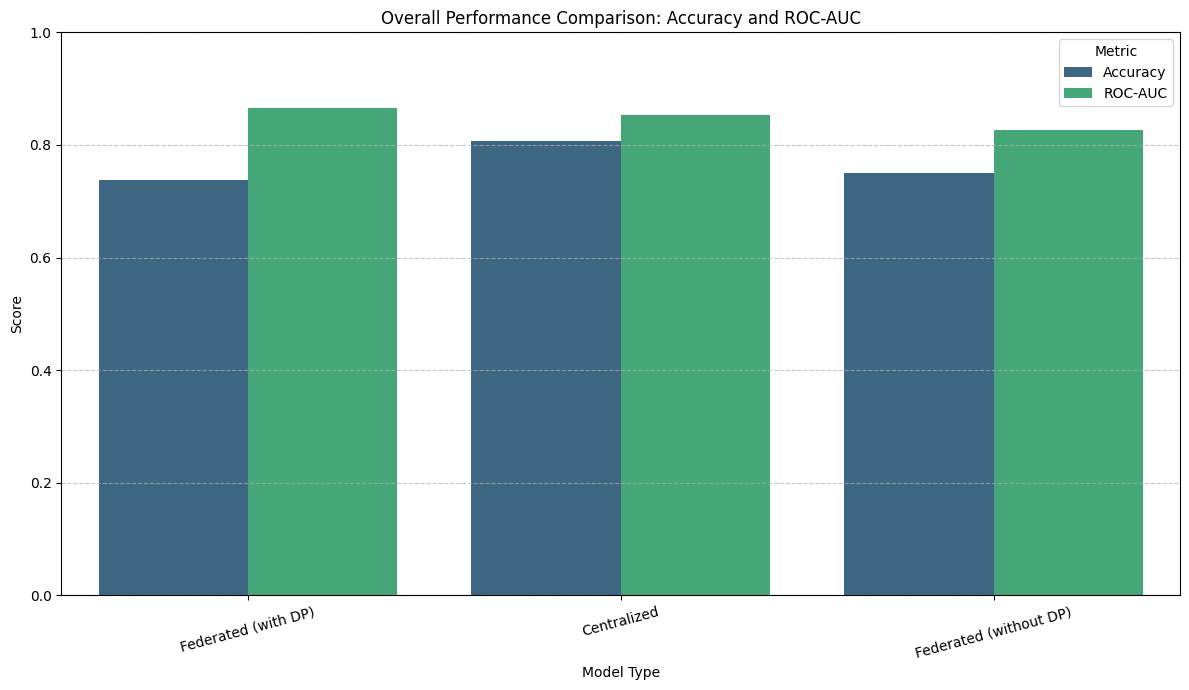

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data for plotting from the available kernel variables
plot_data = {
    'Model Type': [
        'Federated (with DP)', 'Federated (with DP)',
        'Centralized', 'Centralized',
        'Federated (without DP)', 'Federated (without DP)'
    ],
    'Metric': [
        'Accuracy', 'ROC-AUC',
        'Accuracy', 'ROC-AUC',
        'Accuracy', 'ROC-AUC'
    ],
    'Value': [
        acc, roc_auc, # Federated (with DP)
        accuracy_central, roc_auc_central, # Centralized
        overall_accuracy_non_dp, roc_auc_non_dp # Federated (without DP)
    ]
}
df_comparison = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model Type', y='Value', hue='Metric', data=df_comparison, palette='viridis')
plt.title('Overall Performance Comparison: Accuracy and ROC-AUC')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15) # Rotate labels slightly if they overlap
plt.legend(title='Metric')
plt.tight_layout()
plt.show()